# 04 LoCoMotif Visual Study

## Objective
Study already-computed LoCoMotif outputs, visualize motif intervals when available, audit runtime/failures, and compare LoCoMotif with Matrix Profile for thesis presentation.

## Input files
- `results/motifs/locomotif/locomotif_motif_results.parquet`
- `results/motifs/locomotif/locomotif_evaluation.parquet`
- `results/motifs/locomotif/locomotif_runtime.parquet`
- `results/motifs/locomotif/04_locomotif_failures.parquet` if available
- Matrix Profile summary files for comparison

## Output folder
`reports/study_notebooks/figures/locomotif` and `reports/study_notebooks/tables`.

## Thesis relevance
LoCoMotif complements Matrix Profile by targeting variable/local-constrained interval motifs. This notebook treats LoCoMotif as a controlled subset experiment unless full-scale outputs are present.

## Analysis-only safety
This notebook never imports or calls STUMPY, STUMP/MSTUMP, HMM fitting, LoCoMotif search, or any other expensive experiment algorithm. It only reads saved result files and thesis-scope feature parquet files, then produces derived tables and figures.


In [1]:
from pathlib import Path
import sys
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

NOTEBOOK_DIR = Path.cwd() / "HPC workflow" / "HPC_Regime_and_motif_discovery" / "notebooks" / "study"
if NOTEBOOK_DIR.exists() and str(NOTEBOOK_DIR) not in sys.path:
    sys.path.insert(0, str(NOTEBOOK_DIR))

from study_helpers import *

ensure_study_output_dirs()
plt.rcParams.update({
    "figure.figsize": (12, 6),
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
})

print("Project root:", PROJECT_ROOT)
print("Workflow root:", WORKFLOW_ROOT)
print("Study outputs:", REPORT_ROOT)


Project root: /home/i6404275/Final_master_thesis
Workflow root: /home/i6404275/Final_master_thesis/HPC workflow/HPC_Regime_and_motif_discovery
Study outputs: /home/i6404275/Final_master_thesis/HPC workflow/HPC_Regime_and_motif_discovery/reports/study_notebooks


## Load LoCoMotif Results


In [2]:
loco_dir = result_path("motifs", "locomotif")
loco_paths = {
    "motif_results": resolve_existing_file(loco_dir, "locomotif_motif_results.parquet"),
    "evaluation": resolve_existing_file(loco_dir, "locomotif_evaluation.parquet"),
    "runtime": resolve_existing_file(loco_dir, "locomotif_runtime.parquet"),
    "failures": resolve_existing_file(loco_dir, "04_locomotif_failures.parquet"),
}
loco = safe_read_parquet(loco_paths["motif_results"])
loco_eval = safe_read_parquet(loco_paths["evaluation"])
loco_runtime = safe_read_parquet(loco_paths["runtime"])
loco_failures = safe_read_parquet(loco_paths["failures"])
for col in ["motif_start_timestamp", "motif_end_timestamp"]:
    if col in loco.columns:
        loco[col] = pd.to_datetime(loco[col], errors="coerce")


Loaded locomotif_motif_results.parquet: 18,147 rows, 27 columns
Loaded locomotif_evaluation.parquet: 38 rows, 18 columns
Loaded locomotif_runtime.parquet: 662 rows, 18 columns
Missing file: /home/i6404275/Final_master_thesis/HPC workflow/HPC_Regime_and_motif_discovery/results/motifs/locomotif/04_locomotif_failures.parquet


## File Inventory


In [3]:
fig_roots = [RESULTS_ROOT / "figures", RESULTS_ROOT / "figures_parallel"]
figure_files = []
for root in fig_roots:
    if root.exists():
        figure_files.extend(sorted(root.rglob("04_*")))

inventory = pd.DataFrame([
    {
        "file": name,
        "path": str(path),
        "exists": path.exists(),
        "rows": len({"motif_results": loco, "evaluation": loco_eval, "runtime": loco_runtime, "failures": loco_failures}.get(name, pd.DataFrame())),
        "columns": len({"motif_results": loco, "evaluation": loco_eval, "runtime": loco_runtime, "failures": loco_failures}.get(name, pd.DataFrame()).columns),
    }
    for name, path in loco_paths.items()
] + [{
    "file": "figures_04_prefix",
    "path": "; ".join(str(p) for p in fig_roots),
    "exists": bool(figure_files),
    "rows": len(figure_files),
    "columns": 0,
}])
display_table(inventory)
save_table(inventory, "study_locomotif_file_inventory")


,file,path,exists,rows,columns
0,motif_results,/home/i6404275/Final_master_thesis/HPC workflo...,True,18147,27
1,evaluation,/home/i6404275/Final_master_thesis/HPC workflo...,True,38,18
2,runtime,/home/i6404275/Final_master_thesis/HPC workflo...,True,662,18
3,failures,/home/i6404275/Final_master_thesis/HPC workflo...,False,0,0
4,figures_04_prefix,/home/i6404275/Final_master_thesis/HPC workflo...,True,6,0


Saved table: /home/i6404275/Final_master_thesis/HPC workflow/HPC_Regime_and_motif_discovery/reports/study_notebooks/tables/study_locomotif_file_inventory.csv


PosixPath('/home/i6404275/Final_master_thesis/HPC workflow/HPC_Regime_and_motif_discovery/reports/study_notebooks/tables/study_locomotif_file_inventory.csv')

## Scope and Status


In [4]:
scope_rows = []
for label, df in [("motif_results", loco), ("evaluation", loco_eval), ("runtime", loco_runtime), ("failures", loco_failures)]:
    scope_rows.append({
        "source": label,
        "rows": len(df),
        "assets": ", ".join(sorted(df["asset"].dropna().astype(str).unique())) if "asset" in df.columns and not df.empty else "",
        "frequencies": ", ".join(sorted(df["frequency"].dropna().astype(str).unique())) if "frequency" in df.columns and not df.empty else "",
        "modes": ", ".join(sorted(df["mode"].dropna().astype(str).unique())) if "mode" in df.columns and not df.empty else "",
        "regime_methods": ", ".join(sorted(df["regime_method"].dropna().astype(str).unique())) if "regime_method" in df.columns and not df.empty else "",
        "regime_labels": ", ".join(sorted(df["regime_label"].dropna().astype(str).unique())) if "regime_label" in df.columns and not df.empty else "",
        "feature_sets": ", ".join(sorted(df["feature_set"].dropna().astype(str).unique())) if "feature_set" in df.columns and not df.empty else "",
        "status_counts": json.dumps(df["status"].value_counts(dropna=False).to_dict(), default=str) if "status" in df.columns and not df.empty else "",
    })
scope = pd.DataFrame(scope_rows)
display_table(scope)
save_table(scope, "study_locomotif_scope_table")


,source,rows,assets,frequencies,modes,regime_methods,regime_labels,feature_sets,status_counts
0,motif_results,18147,BTCUSDT,15m,"agnostic, conditioned","none, quantile_2_rolling_240, quantile_2_rolli...","all, extreme_vol, high_vol, low_vol","log_return,abs_log_return,rolling_volatility_6...","{""success"": 18147}"
1,evaluation,38,BTCUSDT,15m,"agnostic, conditioned","none, quantile_2_rolling_240, quantile_2_rolli...","all, extreme_vol, high_vol, low_vol",,
2,runtime,662,BTCUSDT,15m,"agnostic, conditioned","none, quantile_2_rolling_240, quantile_2_rolli...","all, extreme_vol, high_vol, low_vol","log_return,abs_log_return,rolling_volatility_6...","{""success"": 662}"
3,failures,0,,,,,,,


Saved table: /home/i6404275/Final_master_thesis/HPC workflow/HPC_Regime_and_motif_discovery/reports/study_notebooks/tables/study_locomotif_scope_table.csv


PosixPath('/home/i6404275/Final_master_thesis/HPC workflow/HPC_Regime_and_motif_discovery/reports/study_notebooks/tables/study_locomotif_scope_table.csv')

## Motif Interval Length Distribution


Saved figure: /home/i6404275/Final_master_thesis/HPC workflow/HPC_Regime_and_motif_discovery/reports/study_notebooks/figures/locomotif/study_locomotif_interval_length_distribution.png, /home/i6404275/Final_master_thesis/HPC workflow/HPC_Regime_and_motif_discovery/reports/study_notebooks/figures/locomotif/study_locomotif_interval_length_distribution.pdf


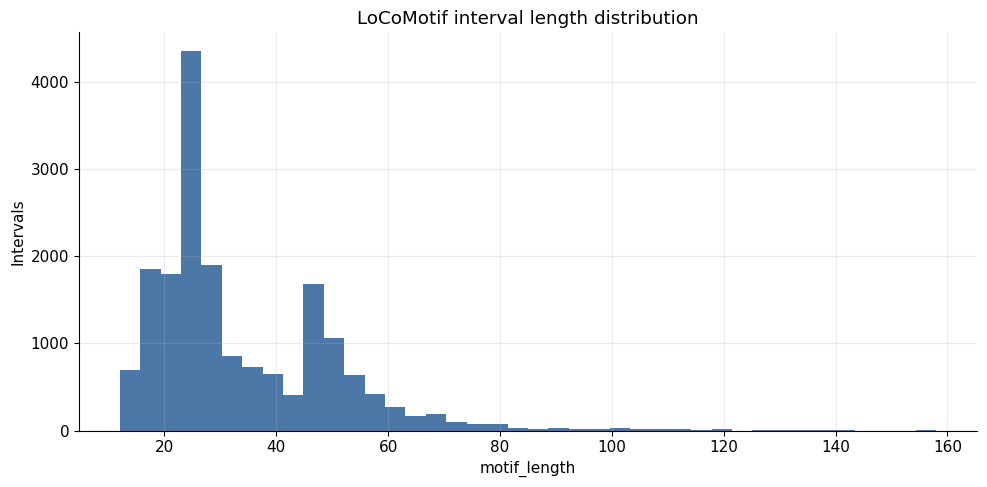

Saved figure: /home/i6404275/Final_master_thesis/HPC workflow/HPC_Regime_and_motif_discovery/reports/study_notebooks/figures/locomotif/study_locomotif_interval_length_by_mode.png, /home/i6404275/Final_master_thesis/HPC workflow/HPC_Regime_and_motif_discovery/reports/study_notebooks/figures/locomotif/study_locomotif_interval_length_by_mode.pdf


/tmp/ipykernel_2350042/1869782215.py:20: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(groups, labels=labels, showfliers=False)


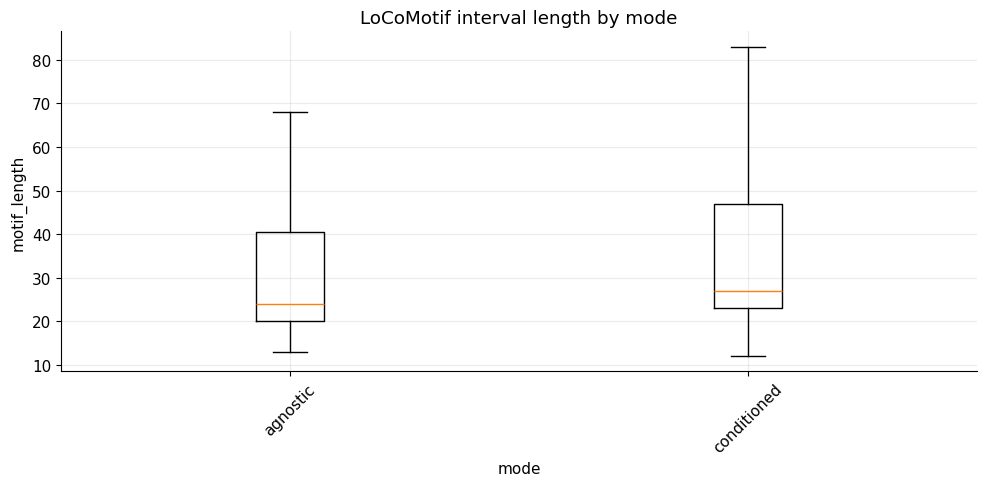

/tmp/ipykernel_2350042/1869782215.py:20: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(groups, labels=labels, showfliers=False)


Saved figure: /home/i6404275/Final_master_thesis/HPC workflow/HPC_Regime_and_motif_discovery/reports/study_notebooks/figures/locomotif/study_locomotif_interval_length_by_regime_label.png, /home/i6404275/Final_master_thesis/HPC workflow/HPC_Regime_and_motif_discovery/reports/study_notebooks/figures/locomotif/study_locomotif_interval_length_by_regime_label.pdf


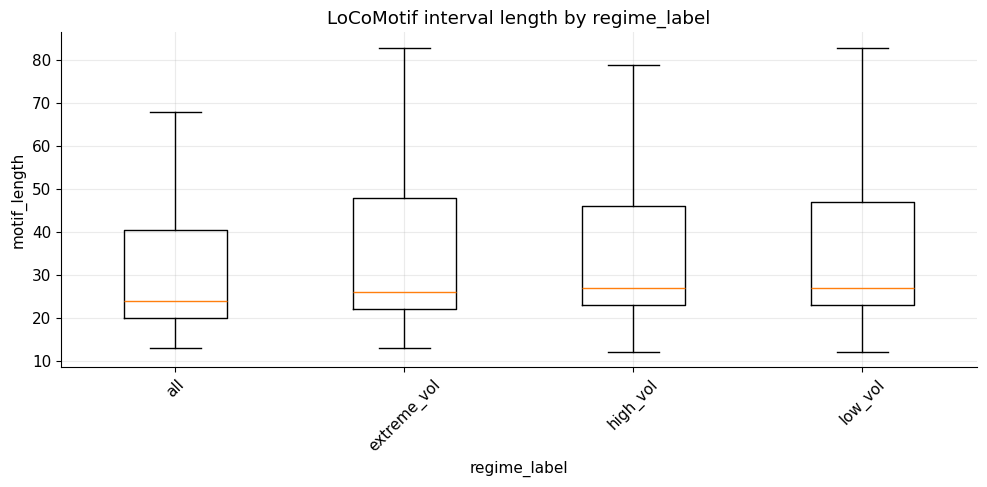

In [5]:
length_col = next((c for c in ["motif_length", "interval_length", "length"] if c in loco.columns and pd.api.types.is_numeric_dtype(loco[c])), None)
if loco.empty or not length_col:
    print("No LoCoMotif interval-length rows are available.")
else:
    fig, ax = plt.subplots(figsize=(10, 5))
    loco[length_col].dropna().plot(kind="hist", bins=40, ax=ax, color="#4C78A8")
    ax.set_title("LoCoMotif interval length distribution")
    ax.set_xlabel(length_col)
    ax.set_ylabel("Intervals")
    fig.tight_layout()
    save_fig(fig, "study_locomotif_interval_length_distribution", FIGURE_DIRS["locomotif"])
    plt.show()

    for by in ["mode", "regime_label"]:
        if by in loco.columns:
            groups = [part[length_col].dropna().to_numpy() for _, part in loco.groupby(by, dropna=False)]
            labels = [str(k) for k, _ in loco.groupby(by, dropna=False)]
            if groups:
                fig, ax = plt.subplots(figsize=(10, 5))
                ax.boxplot(groups, labels=labels, showfliers=False)
                ax.set_title(f"LoCoMotif interval length by {by}")
                ax.set_xlabel(by)
                ax.set_ylabel(length_col)
                ax.tick_params(axis="x", rotation=45)
                fig.tight_layout()
                save_fig(fig, f"study_locomotif_interval_length_by_{by}", FIGURE_DIRS["locomotif"])
                plt.show()


## Recurrence and Evaluation


,asset,frequency,method,mode,regime_method,regime_label,l_min,l_max,rho,number_of_motifs,mean_motif_distance_or_score,recurrence_count,mean_motif_length,median_motif_length,runtime_seconds,time_split_stability,cross_regime_overlap,notes
0,BTCUSDT,15m,locomotif,agnostic,none,all,24,72,0.65,5,NaN,71,22.154930,23.0,113.448029,0.918919,NaN,Real LoCoMotif motif intervals parsed from app...
1,BTCUSDT,15m,locomotif,agnostic,none,all,48,168,0.65,4,NaN,25,67.840000,59.0,8.229156,0.785714,NaN,Real LoCoMotif motif intervals parsed from app...
2,BTCUSDT,15m,locomotif,conditioned,quantile_2_rolling_240,high_vol,24,72,0.65,5,NaN,1003,24.946162,24.0,157.670603,0.138479,NaN,Real LoCoMotif motif intervals parsed from app...
3,BTCUSDT,15m,locomotif,conditioned,quantile_2_rolling_240,high_vol,48,168,0.65,5,NaN,512,50.708984,49.0,76.072504,0.130243,NaN,Real LoCoMotif motif intervals parsed from app...
4,BTCUSDT,15m,locomotif,conditioned,quantile_2_rolling_240,low_vol,24,72,0.65,5,NaN,1277,24.848081,24.0,187.996360,0.370172,NaN,Real LoCoMotif motif intervals parsed from app...
5,BTCUSDT,15m,locomotif,conditioned,quantile_2_rolling_240,low_vol,48,168,0.65,5,NaN,636,51.382075,48.5,89.583152,0.353191,NaN,Real LoCoMotif motif intervals parsed from app...
6,BTCUSDT,15m,locomotif,conditioned,quantile_2_rolling_30,high_vol,24,72,0.65,5,NaN,1003,24.946162,24.0,157.897119,0.138479,NaN,Real LoCoMotif motif intervals parsed from app...
7,BTCUSDT,15m,locomotif,conditioned,quantile_2_rolling_30,high_vol,48,168,0.65,5,NaN,512,50.708984,49.0,76.001191,0.130243,NaN,Real LoCoMotif motif intervals parsed from app...
8,BTCUSDT,15m,locomotif,conditioned,quantile_2_rolling_30,low_vol,24,72,0.65,5,NaN,1277,24.848081,24.0,187.948866,0.370172,NaN,Real LoCoMotif motif intervals parsed from app...
9,BTCUSDT,15m,locomotif,conditioned,quantile_2_rolling_30,low_vol,48,168,0.65,5,NaN,636,51.382075,48.5,89.751180,0.353191,NaN,Real LoCoMotif motif intervals parsed from app...


Saved table: /home/i6404275/Final_master_thesis/HPC workflow/HPC_Regime_and_motif_discovery/reports/study_notebooks/tables/study_locomotif_evaluation_raw.csv


,mode,number_of_motifs_mean,number_of_motifs_median,number_of_motifs_min,number_of_motifs_max,recurrence_count_mean,recurrence_count_median,recurrence_count_min,recurrence_count_max,mean_motif_length_mean,...,median_motif_length_min,median_motif_length_max,time_split_stability_mean,time_split_stability_median,time_split_stability_min,time_split_stability_max,cross_regime_overlap_mean,cross_regime_overlap_median,cross_regime_overlap_min,cross_regime_overlap_max
0,agnostic,4.5,4.5,4,5,48.000000,48.0,25,71,44.997465,...,23.0,59.0,0.852317,0.852317,0.785714,0.918919,NaN,NaN,NaN,NaN
1,conditioned,5.0,5.0,5,5,501.416667,436.0,122,1277,38.649592,...,24.0,52.0,0.457476,0.401549,0.130243,0.820896,NaN,NaN,NaN,NaN


Saved table: /home/i6404275/Final_master_thesis/HPC workflow/HPC_Regime_and_motif_discovery/reports/study_notebooks/tables/study_locomotif_evaluation_by_mode.csv


Saved figure: /home/i6404275/Final_master_thesis/HPC workflow/HPC_Regime_and_motif_discovery/reports/study_notebooks/figures/locomotif/study_locomotif_number_of_motifs_by_mode.png, /home/i6404275/Final_master_thesis/HPC workflow/HPC_Regime_and_motif_discovery/reports/study_notebooks/figures/locomotif/study_locomotif_number_of_motifs_by_mode.pdf


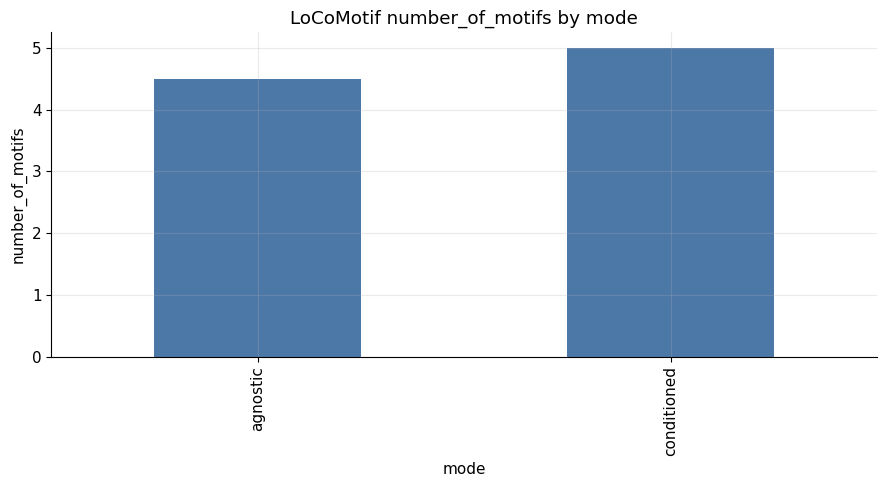

Saved figure: /home/i6404275/Final_master_thesis/HPC workflow/HPC_Regime_and_motif_discovery/reports/study_notebooks/figures/locomotif/study_locomotif_recurrence_count_by_mode.png, /home/i6404275/Final_master_thesis/HPC workflow/HPC_Regime_and_motif_discovery/reports/study_notebooks/figures/locomotif/study_locomotif_recurrence_count_by_mode.pdf


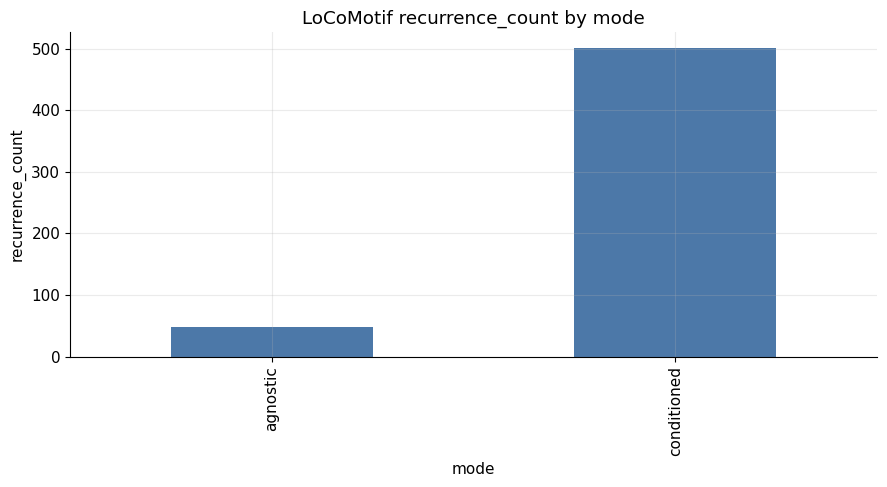

Saved figure: /home/i6404275/Final_master_thesis/HPC workflow/HPC_Regime_and_motif_discovery/reports/study_notebooks/figures/locomotif/study_locomotif_mean_motif_length_by_mode.png, /home/i6404275/Final_master_thesis/HPC workflow/HPC_Regime_and_motif_discovery/reports/study_notebooks/figures/locomotif/study_locomotif_mean_motif_length_by_mode.pdf


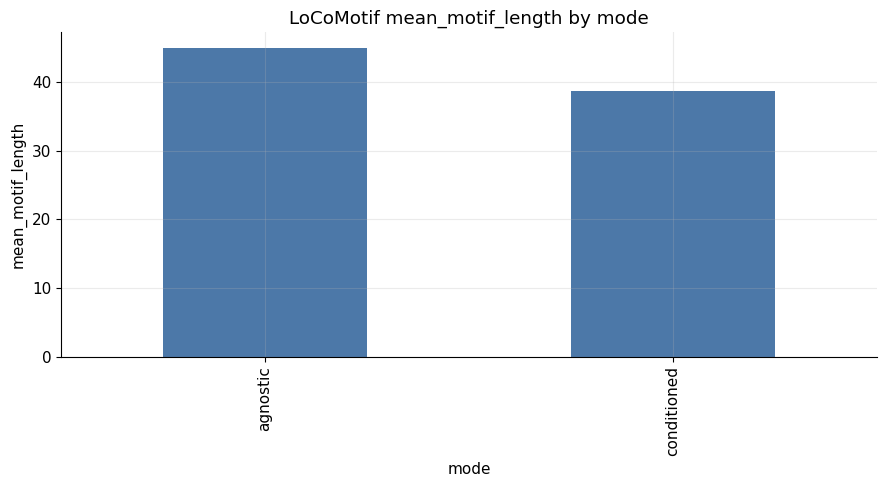

Saved figure: /home/i6404275/Final_master_thesis/HPC workflow/HPC_Regime_and_motif_discovery/reports/study_notebooks/figures/locomotif/study_locomotif_median_motif_length_by_mode.png, /home/i6404275/Final_master_thesis/HPC workflow/HPC_Regime_and_motif_discovery/reports/study_notebooks/figures/locomotif/study_locomotif_median_motif_length_by_mode.pdf


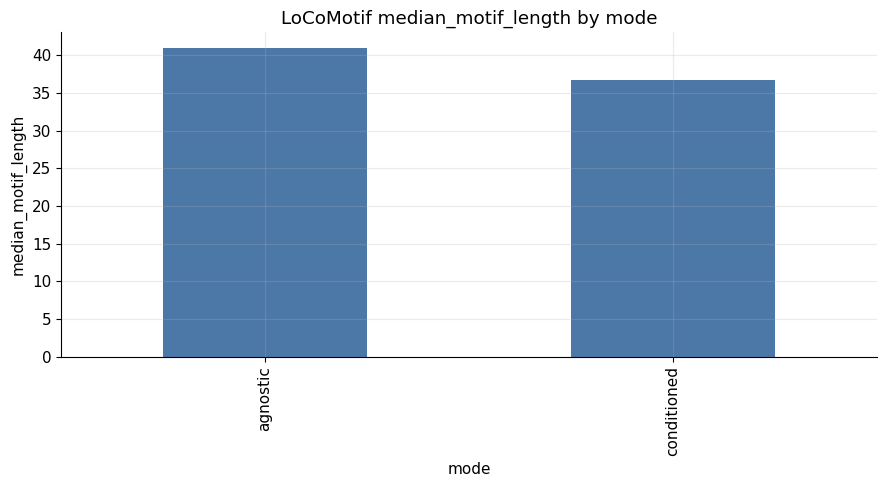

Saved figure: /home/i6404275/Final_master_thesis/HPC workflow/HPC_Regime_and_motif_discovery/reports/study_notebooks/figures/locomotif/study_locomotif_time_split_stability_by_mode.png, /home/i6404275/Final_master_thesis/HPC workflow/HPC_Regime_and_motif_discovery/reports/study_notebooks/figures/locomotif/study_locomotif_time_split_stability_by_mode.pdf


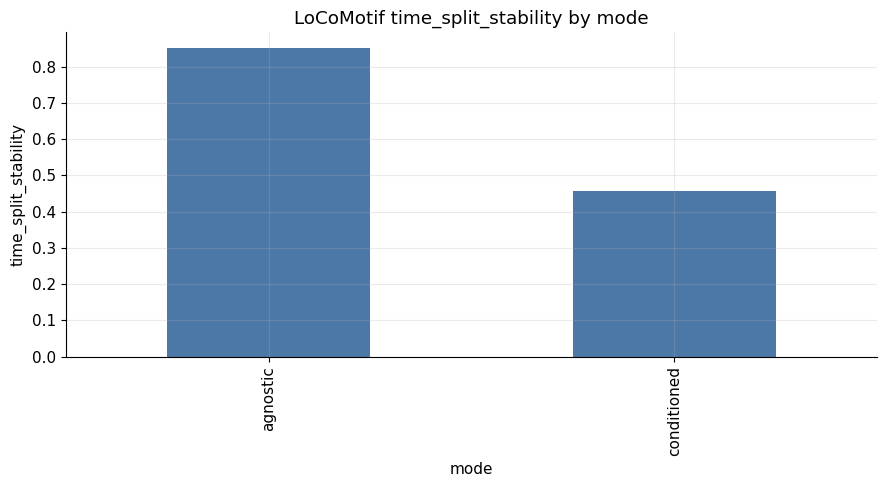

Saved figure: /home/i6404275/Final_master_thesis/HPC workflow/HPC_Regime_and_motif_discovery/reports/study_notebooks/figures/locomotif/study_locomotif_cross_regime_overlap_by_mode.png, /home/i6404275/Final_master_thesis/HPC workflow/HPC_Regime_and_motif_discovery/reports/study_notebooks/figures/locomotif/study_locomotif_cross_regime_overlap_by_mode.pdf


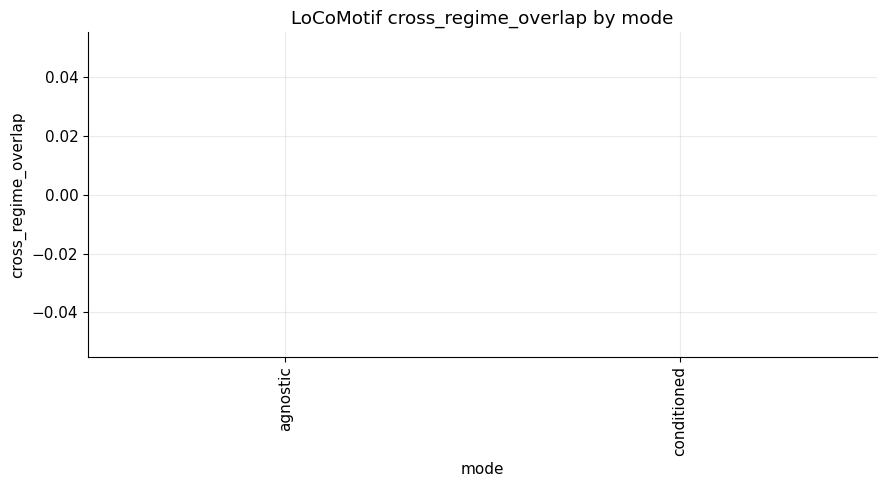

In [6]:
display_table(loco_eval, 20)
save_table(loco_eval, "study_locomotif_evaluation_raw")

metrics = [c for c in ["number_of_motifs", "recurrence_count", "mean_motif_length", "median_motif_length", "time_split_stability", "cross_regime_overlap"] if c in loco_eval.columns]
if not loco_eval.empty and metrics:
    group = "mode" if "mode" in loco_eval.columns else None
    if group:
        summary = loco_eval.groupby(group, dropna=False)[metrics].agg(["mean", "median", "min", "max"])
        summary.columns = ["_".join(c).strip("_") for c in summary.columns.to_flat_index()]
        summary = summary.reset_index()
        display_table(summary)
        save_table(summary, "study_locomotif_evaluation_by_mode")
        for metric in metrics:
            fig, ax = plt.subplots(figsize=(9, 5))
            loco_eval.groupby(group, dropna=False)[metric].mean().plot(kind="bar", ax=ax, color="#4C78A8")
            ax.set_title(f"LoCoMotif {metric} by mode")
            ax.set_ylabel(metric)
            fig.tight_layout()
            save_fig(fig, f"study_locomotif_{metric}_by_mode", FIGURE_DIRS["locomotif"])
            plt.show()
else:
    print("No populated LoCoMotif evaluation metrics are available.")


## Top LoCoMotif Examples


In [7]:
def rank_locomotif(df):
    if df.empty:
        return df
    work = df.copy()
    if "motif_score" in work.columns and pd.api.types.is_numeric_dtype(work["motif_score"]):
        return work.sort_values("motif_score", ascending=False)
    for col in ["recurrence_count", "number_of_motifs", "time_split_stability"]:
        if col in work.columns and pd.api.types.is_numeric_dtype(work[col]):
            return work.sort_values(col, ascending=False)
    return work

def loco_top_table(df, name, n=10):
    ranked = rank_locomotif(df).head(n)
    if ranked.empty:
        print(f"No rows for {name}")
        return ranked
    cols = [c for c in [
        "asset", "frequency", "mode", "regime_method", "regime_label", "feature_set",
        "motif_set_rank", "motif_instance_id", "motif_start", "motif_end",
        "motif_start_timestamp", "motif_end_timestamp", "motif_length",
        "motif_score", "motif_set_size", "number_of_motifs", "recurrence_count",
        "mean_motif_length", "runtime_seconds", "status",
    ] if c in ranked.columns]
    out = ranked[cols]
    display_table(out, n)
    save_table(out, name)
    return out

source = loco if not loco.empty else loco_eval
loco_top_table(source[source["mode"].astype(str).eq("agnostic")] if "mode" in source.columns else pd.DataFrame(), "study_locomotif_top10_agnostic")
loco_top_table(source[source["mode"].astype(str).eq("conditioned")] if "mode" in source.columns else pd.DataFrame(), "study_locomotif_top10_conditioned")
for label in ["high_vol", "low_vol"]:
    loco_top_table(source[source["regime_label"].astype(str).eq(label)] if "regime_label" in source.columns else pd.DataFrame(), f"study_locomotif_top10_{label}")


,asset,frequency,mode,regime_method,regime_label,feature_set,motif_set_rank,motif_instance_id,motif_start,motif_end,motif_start_timestamp,motif_end_timestamp,motif_length,motif_score,motif_set_size,runtime_seconds,status
0,BTCUSDT,15m,agnostic,none,all,"log_return,abs_log_return,rolling_volatility_6...",1,1,1174,1198,2020-01-13 05:30:00+00:00,2020-01-13 11:15:00+00:00,24,NaN,42,1.59786,success
1,BTCUSDT,15m,agnostic,none,all,"log_return,abs_log_return,rolling_volatility_6...",1,2,1174,1198,2020-01-13 05:30:00+00:00,2020-01-13 11:15:00+00:00,24,NaN,42,1.59786,success
2,BTCUSDT,15m,agnostic,none,all,"log_return,abs_log_return,rolling_volatility_6...",1,3,1157,1171,2020-01-13 01:15:00+00:00,2020-01-13 04:30:00+00:00,14,NaN,42,1.59786,success
3,BTCUSDT,15m,agnostic,none,all,"log_return,abs_log_return,rolling_volatility_6...",1,4,1209,1238,2020-01-13 14:15:00+00:00,2020-01-13 21:15:00+00:00,29,NaN,42,1.59786,success
4,BTCUSDT,15m,agnostic,none,all,"log_return,abs_log_return,rolling_volatility_6...",1,5,1141,1158,2020-01-12 21:15:00+00:00,2020-01-13 01:15:00+00:00,17,NaN,42,1.59786,success
5,BTCUSDT,15m,agnostic,none,all,"log_return,abs_log_return,rolling_volatility_6...",1,6,433,456,2020-01-05 12:15:00+00:00,2020-01-05 17:45:00+00:00,23,NaN,42,1.59786,success
6,BTCUSDT,15m,agnostic,none,all,"log_return,abs_log_return,rolling_volatility_6...",1,7,1938,1957,2020-01-21 04:30:00+00:00,2020-01-21 09:00:00+00:00,19,NaN,42,1.59786,success
7,BTCUSDT,15m,agnostic,none,all,"log_return,abs_log_return,rolling_volatility_6...",1,8,310,330,2020-01-04 05:30:00+00:00,2020-01-04 10:15:00+00:00,20,NaN,42,1.59786,success
8,BTCUSDT,15m,agnostic,none,all,"log_return,abs_log_return,rolling_volatility_6...",1,9,458,480,2020-01-05 18:30:00+00:00,2020-01-05 23:45:00+00:00,22,NaN,42,1.59786,success
9,BTCUSDT,15m,agnostic,none,all,"log_return,abs_log_return,rolling_volatility_6...",1,10,381,407,2020-01-04 23:15:00+00:00,2020-01-05 05:30:00+00:00,26,NaN,42,1.59786,success


Saved table: /home/i6404275/Final_master_thesis/HPC workflow/HPC_Regime_and_motif_discovery/reports/study_notebooks/tables/study_locomotif_top10_agnostic.csv


,asset,frequency,mode,regime_method,regime_label,feature_set,motif_set_rank,motif_instance_id,motif_start,motif_end,motif_start_timestamp,motif_end_timestamp,motif_length,motif_score,motif_set_size,runtime_seconds,status
96,BTCUSDT,15m,conditioned,quantile_2_rolling_240,high_vol,"log_return,abs_log_return,rolling_volatility_6...",1,1,1622,1646,2020-03-27 07:45:00+00:00,2020-03-27 13:30:00+00:00,24,NaN,34,0.212504,success
97,BTCUSDT,15m,conditioned,quantile_2_rolling_240,high_vol,"log_return,abs_log_return,rolling_volatility_6...",1,2,1622,1646,2020-03-27 07:45:00+00:00,2020-03-27 13:30:00+00:00,24,NaN,34,0.212504,success
98,BTCUSDT,15m,conditioned,quantile_2_rolling_240,high_vol,"log_return,abs_log_return,rolling_volatility_6...",1,3,1602,1616,2020-03-27 02:45:00+00:00,2020-03-27 06:00:00+00:00,14,NaN,34,0.212504,success
99,BTCUSDT,15m,conditioned,quantile_2_rolling_240,high_vol,"log_return,abs_log_return,rolling_volatility_6...",1,4,1587,1602,2020-03-26 23:00:00+00:00,2020-03-27 02:30:00+00:00,15,NaN,34,0.212504,success
100,BTCUSDT,15m,conditioned,quantile_2_rolling_240,high_vol,"log_return,abs_log_return,rolling_volatility_6...",1,5,1570,1584,2020-03-26 18:45:00+00:00,2020-03-26 22:00:00+00:00,14,NaN,34,0.212504,success
101,BTCUSDT,15m,conditioned,quantile_2_rolling_240,high_vol,"log_return,abs_log_return,rolling_volatility_6...",1,6,1541,1556,2020-03-26 11:30:00+00:00,2020-03-26 15:00:00+00:00,15,NaN,34,0.212504,success
102,BTCUSDT,15m,conditioned,quantile_2_rolling_240,high_vol,"log_return,abs_log_return,rolling_volatility_6...",1,7,149,169,2020-03-11 23:30:00+00:00,2020-03-12 04:15:00+00:00,20,NaN,34,0.212504,success
103,BTCUSDT,15m,conditioned,quantile_2_rolling_240,high_vol,"log_return,abs_log_return,rolling_volatility_6...",1,8,1526,1541,2020-03-26 07:45:00+00:00,2020-03-26 11:15:00+00:00,15,NaN,34,0.212504,success
104,BTCUSDT,15m,conditioned,quantile_2_rolling_240,high_vol,"log_return,abs_log_return,rolling_volatility_6...",1,9,1512,1527,2020-03-26 04:15:00+00:00,2020-03-26 07:45:00+00:00,15,NaN,34,0.212504,success
105,BTCUSDT,15m,conditioned,quantile_2_rolling_240,high_vol,"log_return,abs_log_return,rolling_volatility_6...",1,10,1417,1436,2020-03-25 04:30:00+00:00,2020-03-25 09:00:00+00:00,19,NaN,34,0.212504,success


Saved table: /home/i6404275/Final_master_thesis/HPC workflow/HPC_Regime_and_motif_discovery/reports/study_notebooks/tables/study_locomotif_top10_conditioned.csv


,asset,frequency,mode,regime_method,regime_label,feature_set,motif_set_rank,motif_instance_id,motif_start,motif_end,motif_start_timestamp,motif_end_timestamp,motif_length,motif_score,motif_set_size,runtime_seconds,status
96,BTCUSDT,15m,conditioned,quantile_2_rolling_240,high_vol,"log_return,abs_log_return,rolling_volatility_6...",1,1,1622,1646,2020-03-27 07:45:00+00:00,2020-03-27 13:30:00+00:00,24,NaN,34,0.212504,success
97,BTCUSDT,15m,conditioned,quantile_2_rolling_240,high_vol,"log_return,abs_log_return,rolling_volatility_6...",1,2,1622,1646,2020-03-27 07:45:00+00:00,2020-03-27 13:30:00+00:00,24,NaN,34,0.212504,success
98,BTCUSDT,15m,conditioned,quantile_2_rolling_240,high_vol,"log_return,abs_log_return,rolling_volatility_6...",1,3,1602,1616,2020-03-27 02:45:00+00:00,2020-03-27 06:00:00+00:00,14,NaN,34,0.212504,success
99,BTCUSDT,15m,conditioned,quantile_2_rolling_240,high_vol,"log_return,abs_log_return,rolling_volatility_6...",1,4,1587,1602,2020-03-26 23:00:00+00:00,2020-03-27 02:30:00+00:00,15,NaN,34,0.212504,success
100,BTCUSDT,15m,conditioned,quantile_2_rolling_240,high_vol,"log_return,abs_log_return,rolling_volatility_6...",1,5,1570,1584,2020-03-26 18:45:00+00:00,2020-03-26 22:00:00+00:00,14,NaN,34,0.212504,success
101,BTCUSDT,15m,conditioned,quantile_2_rolling_240,high_vol,"log_return,abs_log_return,rolling_volatility_6...",1,6,1541,1556,2020-03-26 11:30:00+00:00,2020-03-26 15:00:00+00:00,15,NaN,34,0.212504,success
102,BTCUSDT,15m,conditioned,quantile_2_rolling_240,high_vol,"log_return,abs_log_return,rolling_volatility_6...",1,7,149,169,2020-03-11 23:30:00+00:00,2020-03-12 04:15:00+00:00,20,NaN,34,0.212504,success
103,BTCUSDT,15m,conditioned,quantile_2_rolling_240,high_vol,"log_return,abs_log_return,rolling_volatility_6...",1,8,1526,1541,2020-03-26 07:45:00+00:00,2020-03-26 11:15:00+00:00,15,NaN,34,0.212504,success
104,BTCUSDT,15m,conditioned,quantile_2_rolling_240,high_vol,"log_return,abs_log_return,rolling_volatility_6...",1,9,1512,1527,2020-03-26 04:15:00+00:00,2020-03-26 07:45:00+00:00,15,NaN,34,0.212504,success
105,BTCUSDT,15m,conditioned,quantile_2_rolling_240,high_vol,"log_return,abs_log_return,rolling_volatility_6...",1,10,1417,1436,2020-03-25 04:30:00+00:00,2020-03-25 09:00:00+00:00,19,NaN,34,0.212504,success


Saved table: /home/i6404275/Final_master_thesis/HPC workflow/HPC_Regime_and_motif_discovery/reports/study_notebooks/tables/study_locomotif_top10_high_vol.csv


,asset,frequency,mode,regime_method,regime_label,feature_set,motif_set_rank,motif_instance_id,motif_start,motif_end,motif_start_timestamp,motif_end_timestamp,motif_length,motif_score,motif_set_size,runtime_seconds,status
244,BTCUSDT,15m,conditioned,quantile_2_rolling_240,low_vol,"log_return,abs_log_return,rolling_volatility_6...",1,1,418,442,2020-06-21 02:30:00+00:00,2020-06-21 08:15:00+00:00,24,NaN,14,0.052668,success
245,BTCUSDT,15m,conditioned,quantile_2_rolling_240,low_vol,"log_return,abs_log_return,rolling_volatility_6...",1,2,418,442,2020-06-21 02:30:00+00:00,2020-06-21 08:15:00+00:00,24,NaN,14,0.052668,success
246,BTCUSDT,15m,conditioned,quantile_2_rolling_240,low_vol,"log_return,abs_log_return,rolling_volatility_6...",1,3,403,420,2020-06-20 22:45:00+00:00,2020-06-21 02:45:00+00:00,17,NaN,14,0.052668,success
247,BTCUSDT,15m,conditioned,quantile_2_rolling_240,low_vol,"log_return,abs_log_return,rolling_volatility_6...",1,4,440,480,2020-06-21 08:00:00+00:00,2020-06-21 17:45:00+00:00,40,NaN,14,0.052668,success
248,BTCUSDT,15m,conditioned,quantile_2_rolling_240,low_vol,"log_return,abs_log_return,rolling_volatility_6...",1,5,474,508,2020-06-21 16:30:00+00:00,2020-06-22 00:45:00+00:00,34,NaN,14,0.052668,success
249,BTCUSDT,15m,conditioned,quantile_2_rolling_240,low_vol,"log_return,abs_log_return,rolling_volatility_6...",1,6,338,366,2020-06-20 06:30:00+00:00,2020-06-20 13:15:00+00:00,28,NaN,14,0.052668,success
250,BTCUSDT,15m,conditioned,quantile_2_rolling_240,low_vol,"log_return,abs_log_return,rolling_volatility_6...",1,7,317,333,2020-06-20 01:15:00+00:00,2020-06-20 05:00:00+00:00,16,NaN,14,0.052668,success
251,BTCUSDT,15m,conditioned,quantile_2_rolling_240,low_vol,"log_return,abs_log_return,rolling_volatility_6...",1,8,175,194,2020-06-18 13:45:00+00:00,2020-06-18 18:15:00+00:00,19,NaN,14,0.052668,success
252,BTCUSDT,15m,conditioned,quantile_2_rolling_240,low_vol,"log_return,abs_log_return,rolling_volatility_6...",1,9,154,177,2020-06-18 08:30:00+00:00,2020-06-18 14:00:00+00:00,23,NaN,14,0.052668,success
253,BTCUSDT,15m,conditioned,quantile_2_rolling_240,low_vol,"log_return,abs_log_return,rolling_volatility_6...",1,10,137,156,2020-06-18 04:15:00+00:00,2020-06-18 08:45:00+00:00,19,NaN,14,0.052668,success


Saved table: /home/i6404275/Final_master_thesis/HPC workflow/HPC_Regime_and_motif_discovery/reports/study_notebooks/tables/study_locomotif_top10_low_vol.csv


## Interval Illustrations


Loaded BTCUSDT_15m_features_2020_2025.parquet: 210,280 rows, 19 columns


Saved figure: /home/i6404275/Final_master_thesis/HPC workflow/HPC_Regime_and_motif_discovery/reports/study_notebooks/figures/locomotif/study_locomotif_BTCUSDT_15m_agnostic_intervals.png, /home/i6404275/Final_master_thesis/HPC workflow/HPC_Regime_and_motif_discovery/reports/study_notebooks/figures/locomotif/study_locomotif_BTCUSDT_15m_agnostic_intervals.pdf


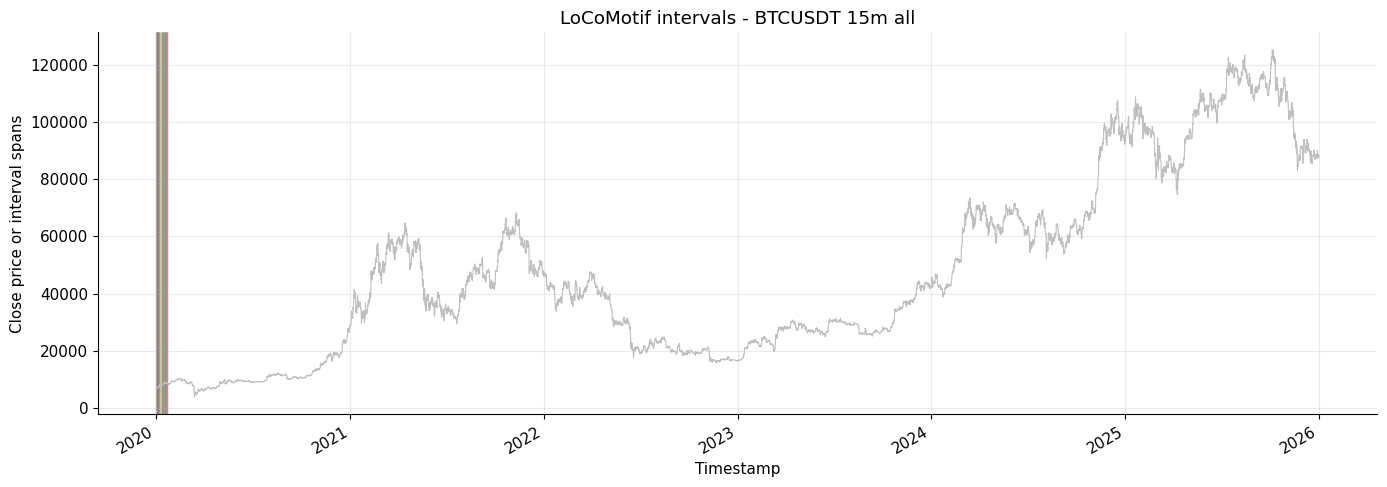

Loaded BTCUSDT_15m_features_2020_2025.parquet: 210,280 rows, 19 columns


Saved figure: /home/i6404275/Final_master_thesis/HPC workflow/HPC_Regime_and_motif_discovery/reports/study_notebooks/figures/locomotif/study_locomotif_BTCUSDT_15m_high_vol_intervals.png, /home/i6404275/Final_master_thesis/HPC workflow/HPC_Regime_and_motif_discovery/reports/study_notebooks/figures/locomotif/study_locomotif_BTCUSDT_15m_high_vol_intervals.pdf


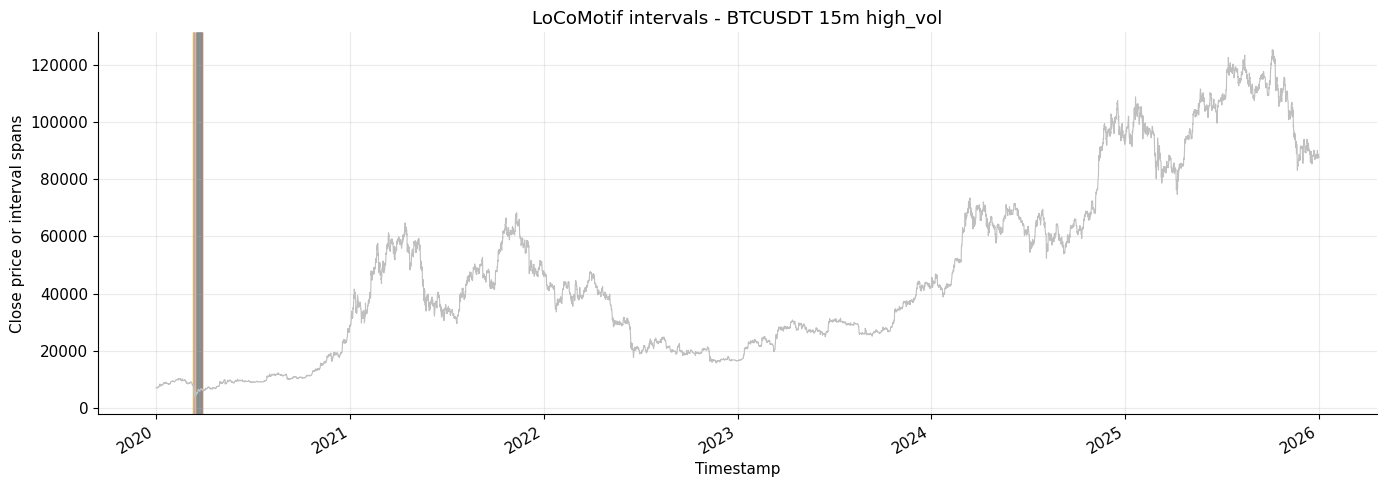

Loaded BTCUSDT_15m_features_2020_2025.parquet: 210,280 rows, 19 columns


Saved figure: /home/i6404275/Final_master_thesis/HPC workflow/HPC_Regime_and_motif_discovery/reports/study_notebooks/figures/locomotif/study_locomotif_BTCUSDT_15m_low_vol_intervals.png, /home/i6404275/Final_master_thesis/HPC workflow/HPC_Regime_and_motif_discovery/reports/study_notebooks/figures/locomotif/study_locomotif_BTCUSDT_15m_low_vol_intervals.pdf


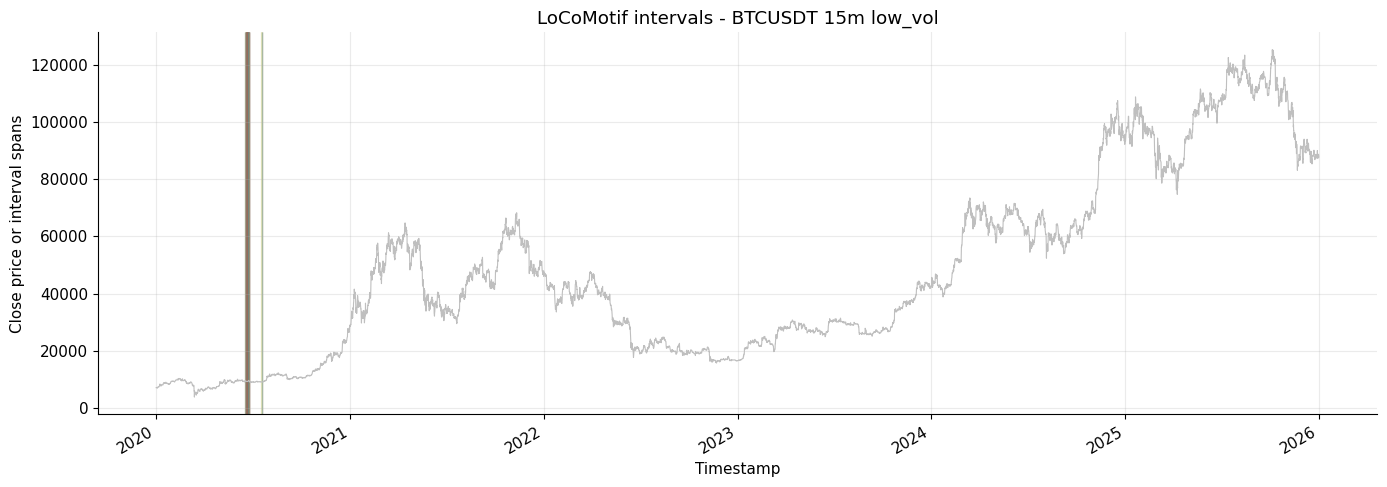

,figure_path
0,/home/i6404275/Final_master_thesis/HPC workflo...
1,/home/i6404275/Final_master_thesis/HPC workflo...
2,/home/i6404275/Final_master_thesis/HPC workflo...
3,/home/i6404275/Final_master_thesis/HPC workflo...
4,/home/i6404275/Final_master_thesis/HPC workflo...
5,/home/i6404275/Final_master_thesis/HPC workflo...


Saved table: /home/i6404275/Final_master_thesis/HPC workflow/HPC_Regime_and_motif_discovery/reports/study_notebooks/tables/study_locomotif_existing_figure_inventory.csv


In [8]:
def plot_locomotif_timeline(df, asset, frequency, regime_label=None, filename="study_locomotif_timeline"):
    subset = filter_scope(df, asset, frequency)
    if regime_label and "regime_label" in subset.columns:
        subset = subset[subset["regime_label"].astype(str).eq(regime_label)]
    if subset.empty:
        print(f"No LoCoMotif intervals for {asset} {frequency} {regime_label or ''}")
        return
    feature = load_feature_data(asset, frequency)
    ts = timestamp_column(feature)
    fig, ax = plt.subplots(figsize=(14, 5))
    if not feature.empty and ts and "close" in feature.columns:
        sampled = feature[[ts, "close"]].dropna().sort_values(ts)
        if len(sampled) > 8000:
            sampled = sampled.iloc[:: int(np.ceil(len(sampled) / 8000))]
        ax.plot(sampled[ts], sampled["close"], color="0.75", linewidth=0.8, label="close")
    draw = subset.head(50)
    for j, (_, row) in enumerate(draw.iterrows()):
        start = row.get("motif_start_timestamp")
        end = row.get("motif_end_timestamp")
        if pd.notna(start) and pd.notna(end):
            ax.axvspan(pd.to_datetime(start), pd.to_datetime(end), color=plt.cm.tab10(j % 10), alpha=0.2)
    ax.set_title(f"LoCoMotif intervals - {asset} {frequency} {regime_label or 'all'}")
    ax.set_xlabel("Timestamp")
    ax.set_ylabel("Close price or interval spans")
    fig.autofmt_xdate()
    fig.tight_layout()
    save_fig(fig, filename, FIGURE_DIRS["locomotif"])
    plt.show()

plot_locomotif_timeline(loco, "BTCUSDT", "15m", None, "study_locomotif_BTCUSDT_15m_agnostic_intervals")
plot_locomotif_timeline(loco, "BTCUSDT", "15m", "high_vol", "study_locomotif_BTCUSDT_15m_high_vol_intervals")
plot_locomotif_timeline(loco, "BTCUSDT", "15m", "low_vol", "study_locomotif_BTCUSDT_15m_low_vol_intervals")

if figure_files:
    fig_table = pd.DataFrame({"figure_path": [str(p) for p in figure_files]})
    display_table(fig_table, 20)
    save_table(fig_table, "study_locomotif_existing_figure_inventory")
else:
    print("No existing LoCoMotif figures with prefix 04_ were found.")


## Runtime and Failure Audit


In [9]:
display_table(loco_runtime, 30)
save_table(loco_runtime, "study_locomotif_runtime_raw")
if "status" in loco_runtime.columns and not loco_runtime.empty:
    status_counts = loco_runtime["status"].value_counts(dropna=False).rename_axis("status").reset_index(name="rows")
    display_table(status_counts)
    save_table(status_counts, "study_locomotif_runtime_status_counts")

if not loco_paths["failures"].exists():
    print("LoCoMotif failure file is not available.")
elif loco_failures.empty:
    print("LoCoMotif failure file exists and contains no rows; no internal failures recorded in that file.")
else:
    display_table(loco_failures, 30)
    save_table(loco_failures, "study_locomotif_failures")

print("LoCoMotif is reported as a controlled subset experiment rather than a full-scale benchmark.")


,module,raw_motif_sets_count,runtime_seconds,rows,asset,frequency,mode,regime_method,regime_label,segment_id,feature_set,l_min,l_max,rho,nb,overlap,warping,status
0,locomotif.locomotif,5,1.597860,71,BTCUSDT,15m,agnostic,none,all,full_series,"log_return,abs_log_return,rolling_volatility_6...",24,72,0.65,5,0.2,True,success
1,locomotif.locomotif,4,0.329166,25,BTCUSDT,15m,agnostic,none,all,full_series,"log_return,abs_log_return,rolling_volatility_6...",48,168,0.65,5,0.2,True,success
2,locomotif.locomotif,5,0.212504,59,BTCUSDT,15m,conditioned,quantile_2_rolling_240,high_vol,high_vol_0001,"log_return,abs_log_return,rolling_volatility_6...",24,72,0.65,5,0.2,True,success
3,locomotif.locomotif,3,0.191963,26,BTCUSDT,15m,conditioned,quantile_2_rolling_240,high_vol,high_vol_0001,"log_return,abs_log_return,rolling_volatility_6...",48,168,0.65,5,0.2,True,success
4,locomotif.locomotif,5,0.057674,27,BTCUSDT,15m,conditioned,quantile_2_rolling_240,high_vol,high_vol_0002,"log_return,abs_log_return,rolling_volatility_6...",24,72,0.65,5,0.2,True,success
5,locomotif.locomotif,2,0.050602,13,BTCUSDT,15m,conditioned,quantile_2_rolling_240,high_vol,high_vol_0002,"log_return,abs_log_return,rolling_volatility_6...",48,168,0.65,5,0.2,True,success
6,locomotif.locomotif,2,0.031606,17,BTCUSDT,15m,conditioned,quantile_2_rolling_240,high_vol,high_vol_0003,"log_return,abs_log_return,rolling_volatility_6...",24,72,0.65,5,0.2,True,success
7,locomotif.locomotif,1,0.027383,6,BTCUSDT,15m,conditioned,quantile_2_rolling_240,high_vol,high_vol_0003,"log_return,abs_log_return,rolling_volatility_6...",48,168,0.65,5,0.2,True,success
8,locomotif.locomotif,4,0.052668,30,BTCUSDT,15m,conditioned,quantile_2_rolling_240,low_vol,low_vol_0004,"log_return,abs_log_return,rolling_volatility_6...",24,72,0.65,5,0.2,True,success
9,locomotif.locomotif,3,0.052371,15,BTCUSDT,15m,conditioned,quantile_2_rolling_240,low_vol,low_vol_0004,"log_return,abs_log_return,rolling_volatility_6...",48,168,0.65,5,0.2,True,success


Saved table: /home/i6404275/Final_master_thesis/HPC workflow/HPC_Regime_and_motif_discovery/reports/study_notebooks/tables/study_locomotif_runtime_raw.csv


,status,rows
0,success,662


Saved table: /home/i6404275/Final_master_thesis/HPC workflow/HPC_Regime_and_motif_discovery/reports/study_notebooks/tables/study_locomotif_runtime_status_counts.csv
LoCoMotif failure file is not available.
LoCoMotif is reported as a controlled subset experiment rather than a full-scale benchmark.


## LoCoMotif vs Matrix Profile


In [10]:
mp_dir = result_path("motifs", "matrix_profile")
mp_results = safe_read_parquet(resolve_existing_file(mp_dir, "matrix_profile_motif_results.parquet"))
mp_eval = safe_read_parquet(resolve_existing_file(mp_dir, "matrix_profile_evaluation.parquet"))
mp_runtime = safe_read_parquet(resolve_existing_file(mp_dir, "matrix_profile_runtime.parquet"))

comparison = pd.DataFrame([
    {"Aspect": "Motif type", "Matrix Profile": "fixed-length subsequences", "LoCoMotif": "variable/local-constrained intervals"},
    {"Aspect": "Scale completed", "Matrix Profile": "full controlled benchmark", "LoCoMotif": "controlled subset"},
    {"Aspect": "Result rows", "Matrix Profile": len(mp_results), "LoCoMotif": len(loco)},
    {"Aspect": "Evaluation rows", "Matrix Profile": len(mp_eval), "LoCoMotif": len(loco_eval)},
    {"Aspect": "Runtime rows", "Matrix Profile": len(mp_runtime), "LoCoMotif": len(loco_runtime)},
    {"Aspect": "Strength", "Matrix Profile": "scalable baseline", "LoCoMotif": "flexible variable-length motif structure"},
    {"Aspect": "Limitation", "Matrix Profile": "fixed-length windows", "LoCoMotif": "more computationally constrained"},
])
display_table(comparison, 10)
save_table(comparison, "study_locomotif_vs_matrix_profile_comparison")


Loaded matrix_profile_motif_results.parquet: 81,987 rows, 33 columns
Loaded matrix_profile_evaluation.parquet: 1,384 rows, 16 columns
Loaded matrix_profile_runtime.parquet: 368 rows, 7 columns


,Aspect,Matrix Profile,LoCoMotif
0,Motif type,fixed-length subsequences,variable/local-constrained intervals
1,Scale completed,full controlled benchmark,controlled subset
2,Result rows,81987,18147
3,Evaluation rows,1384,38
4,Runtime rows,368,662
5,Strength,scalable baseline,flexible variable-length motif structure
6,Limitation,fixed-length windows,more computationally constrained


Saved table: /home/i6404275/Final_master_thesis/HPC workflow/HPC_Regime_and_motif_discovery/reports/study_notebooks/tables/study_locomotif_vs_matrix_profile_comparison.csv


PosixPath('/home/i6404275/Final_master_thesis/HPC workflow/HPC_Regime_and_motif_discovery/reports/study_notebooks/tables/study_locomotif_vs_matrix_profile_comparison.csv')

## Key findings
LoCoMotif adds a variable/local-constrained interval perspective when populated interval or evaluation rows are available. Runtime and failure tables determine whether the run should be presented as completed, partial, or empty.

## Thesis-safe interpretation
LoCoMotif should be presented as a complementary controlled subset experiment unless the saved files show full-scale coverage. It supports the Matrix Profile results by testing a more flexible motif formulation, but it should not be framed as a like-for-like scalability benchmark unless the result files support that claim.

## Limitations
This notebook does not rerun LoCoMotif. Empty motif or evaluation outputs mean no motif-quality numerical claims can be made from LoCoMotif rows. Existing figures are inventoried but not treated as new evidence unless their source files are present.

## Recommended figures for thesis
- LoCoMotif interval timeline when interval rows are available
- Runtime status counts
- LoCoMotif vs Matrix Profile comparison table
- Existing selected `04_` figures from the controlled subset run
